In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation

In [2]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

<Axes: >

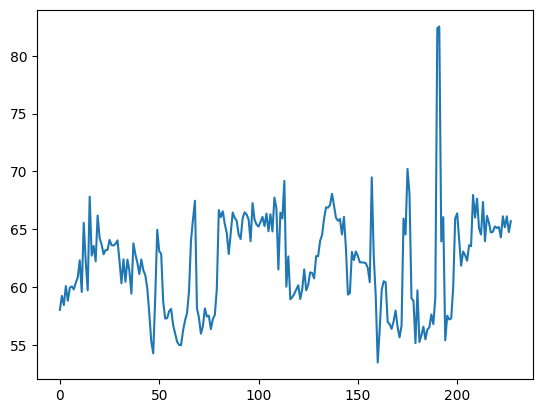

In [3]:
df_local = pd.read_csv("/home/gus/Documents/REPOS/aguspenas/wg-DataAnalysis/data/blink-experiment-local.csv", encoding="latin1")

df_local_wg = df_local[~df_local['webgazer_data'].isnull()]

df_local_wg = pd.DataFrame(json.loads(df_local_wg['webgazer_data'].iloc[5]))

df_local_wg['dz'].astype(float).plot()

In [4]:
file_path = '/home/gus/Documents/REPOS/aguspenas/wg-DataAnalysis/data/data.json'

with open(file_path, 'r', encoding='latin1') as f:
    data = json.load(f)



In [11]:
data['experiment_runs'][0].keys()

dict_keys(['subject', 'status', 'records', 'start_date', 'end_date'])

In [87]:
suj_number = 1
text_data = data['experiment_runs'][suj_number]['records'][1]['data']

parsed_data = json.loads(text_data)

df_from_dataprue = pd.DataFrame(parsed_data)

df_from_dataprue.head()

,load_time,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_start_time,success,item_width_mm,item_height_mm,item_width_px,...,rt,item_width_deg,px2deg,win_width_deg,win_height_deg,webgazer_data,webgazer_targets,stimulus,response,events
0,268.0,webgazer-init-camera,0,24000,0.0-0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,events-tracking-start,1,24002,0.0-1.0,2025-07-15T22:37:51.533Z,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,fullscreen,2,47995,0.0-2.0,NaN,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,virtual-chinrest,3,150842,0.0-3.0,NaN,NaN,85.6,53.98,464.0,...,102850.0,10.171404,45.618089,31.566425,19.729016,"[{'x': 0, 'y': 0, 't': 4, 'importantKeypoints'...",{},NaN,NaN,NaN
4,NaN,virtual-chinrest,4,207455,0.0-4.0,NaN,NaN,85.6,53.98,460.0,...,56612.0,10.527172,43.696445,32.954626,20.596641,"[{'x': 0, 'y': 0, 't': 2, 'importantKeypoints'...",{},NaN,NaN,NaN


<Axes: >

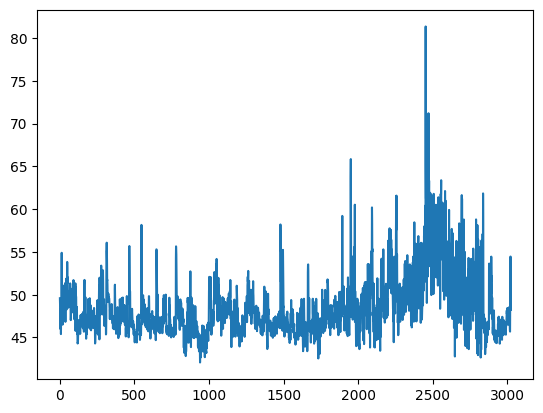

In [88]:
df_dataprue_wg = df_from_dataprue[~df_from_dataprue['webgazer_data'].isnull()]

trial_num = 0
df_dataprue_wg = pd.DataFrame(df_dataprue_wg['webgazer_data'].iloc[trial_num]).reset_index().rename(columns={'index': 'trial'})


df_dataprue_wg['dz'].astype(float).plot()

In [89]:
df_dataprue_wg

,trial,x,y,t,importantKeypoints,dz
0,0,0,0,4,"{'noseX': 328.9, 'noseY': 297.79, 'topY': 171....",49.59
1,1,0,0,40,"{'noseX': 329.72, 'noseY': 296.36, 'topY': 170...",48.92
2,2,0,0,72,"{'noseX': 329.19, 'noseY': 297.44, 'topY': 170...",46.02
3,3,0,0,107,"{'noseX': 329.55, 'noseY': 294.8, 'topY': 170....",48.08
4,4,0,0,139,"{'noseX': 330.29, 'noseY': 293.78, 'topY': 169...",47.04
...,...,...,...,...,...,...
3020,3020,0,0,102682,"{'noseX': 303.9, 'noseY': 309.95, 'topY': 183....",49.61
3021,3021,0,0,102717,"{'noseX': 303.52, 'noseY': 309.59, 'topY': 183...",52.88
3022,3022,0,0,102751,"{'noseX': 303.53, 'noseY': 308.77, 'topY': 182...",54.46
3023,3023,0,0,102788,"{'noseX': 302.82, 'noseY': 309.29, 'topY': 182...",49.82


In [90]:
df_dataprue_wg['importantKeypoints'].iloc[1]

{'noseX': 329.72,
 'noseY': 296.36,
 'topY': 170.43,
 'bottomY': 392.07,
 'leftEarX': 408.85,
 'rightearX': 232.95,
 'rightEyeTopArc': [{'x': 349.05, 'y': 240.58, 'point': 463},
  {'x': 354.01, 'y': 237.93, 'point': 398},
  {'x': 358.89, 'y': 235.06, 'point': 384},
  {'x': 365.64, 'y': 233.61, 'point': 385},
  {'x': 372.5, 'y': 234.03, 'point': 386},
  {'x': 378.64, 'y': 235.49, 'point': 387},
  {'x': 381.92, 'y': 237.33, 'point': 388},
  {'x': 383.6, 'y': 238.52, 'point': 466},
  {'x': 384.86, 'y': 239.36, 'point': 263},
  {'x': 384.13, 'y': 244.24, 'point': 255}],
 'rightEyeBottomArc': [{'x': 349.05, 'y': 240.58, 'point': 463},
  {'x': 350.98, 'y': 242.89, 'point': 341},
  {'x': 354.38, 'y': 244.62, 'point': 256},
  {'x': 360.04, 'y': 246.71, 'point': 252},
  {'x': 367.4, 'y': 247.92, 'point': 253},
  {'x': 374.68, 'y': 248.58, 'point': 254},
  {'x': 380.44, 'y': 247.29, 'point': 339},
  {'x': 384.13, 'y': 244.24, 'point': 255}],
 'leftEyeTopArc': [{'x': 271.95, 'y': 237.78, 'point':

In [91]:
blinkDistance = distance.BlinkDistance()
blinkColors = Colors()
blinkCorrelations = Correlation()

df_webgazer = df_dataprue_wg.copy()


df_webgazer["isBlinkByEar"] = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
# df_webgazer["isBlinkColors"] = df_webgazer.apply(
#     lambda row: blinkColors.isBlinkByColors(
#         list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
#     ),
#     axis=1,
# )


# df_webgazer["isBlinkByCorrelation"] = df_webgazer.apply(
#     lambda row: blinkCorrelations.isBlinkByCorrelation(
#         list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
#     ),
#     axis=1,
# )


# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,trial,x,y,t,importantKeypoints,dz,isBlinkByEar,isBlinkByDistance
0,0,0,0,4,"{'noseX': 328.9, 'noseY': 297.79, 'topY': 171....",49.59,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
1,1,0,0,40,"{'noseX': 329.72, 'noseY': 296.36, 'topY': 170...",48.92,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,2,0,0,72,"{'noseX': 329.19, 'noseY': 297.44, 'topY': 170...",46.02,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,3,0,0,107,"{'noseX': 329.55, 'noseY': 294.8, 'topY': 170....",48.08,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
4,4,0,0,139,"{'noseX': 330.29, 'noseY': 293.78, 'topY': 169...",47.04,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...
3020,3020,0,0,102682,"{'noseX': 303.9, 'noseY': 309.95, 'topY': 183....",49.61,"[False, False, False, False, False, False, Fal...","[False, False, False, True, False, False, Fals..."
3021,3021,0,0,102717,"{'noseX': 303.52, 'noseY': 309.59, 'topY': 183...",52.88,"[False, False, False, False, False, False, Fal...","[False, False, True, True, False, False, False..."
3022,3022,0,0,102751,"{'noseX': 303.53, 'noseY': 308.77, 'topY': 182...",54.46,"[False, False, False, False, False, False, Fal...","[False, False, True, True, False, False, False..."
3023,3023,0,0,102788,"{'noseX': 302.82, 'noseY': 309.29, 'topY': 182...",49.82,"[False, False, False, False, False, False, Fal...","[False, False, False, True, False, False, Fals..."


In [92]:
df_webgazer['isBlinkByEar'].value_counts()

isBlinkByEar
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]    2794
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True]        92
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True]       76
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True]         29
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True]          15
[False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True]            9
[False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True]              5
[False, False, False, False, False, False,

In [93]:
df_webgazer['isBlinkByDistance'].value_counts()

isBlinkByDistance
[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]    2289
[False, False, False, True, False, False, False, False, False, False, False, False, False, False, False]      713
[False, False, True, True, False, False, False, False, False, False, False, False, False, False, False]        11
[False, False, True, True, False, False, False, False, False, True, False, False, False, False, False]          6
[False, False, True, True, False, False, False, True, True, True, False, False, True, True, True]               3
[False, False, True, True, False, False, False, False, True, True, False, False, False, False, False]           2
[False, False, True, True, False, False, True, True, True, True, False, True, True, True, True]                 1
Name: count, dtype: int64

In [77]:
# Define the conditions for the different blink types
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: any(x))

# Initialize the plot
plt.figure(figsize=(14, 8))

# Plot the blink data using different colors for each type
plt.scatter(
    df_webgazer[df_webgazer["Blink_sample"]].t,
    df_webgazer[df_webgazer["Blink_sample"]].trial,
    color="black",
    label="Blink sample",
    s=20,
)

# Add labels and legend
plt.title("Blink Scatter Plot")
plt.xlabel("Time (ms)")
plt.ylabel("Trial")
plt.legend(loc="upper right")

# Show plot
plt.show()


AttributeError: 'DataFrame' object has no attribute 'trial'

<Figure size 1400x800 with 0 Axes>

In [ ]:
df_webgazer["Blink_sample3_diff"] = df_webgazer["Blink_sample3"].diff()
#df_webgazer.groupby("trial")["Blink_sample3_diff"].sum()

df_webgazer["blinks"] = df_webgazer[df_webgazer['trial']==1].groupby("Blink_sample3_diff")["Blink_sample3_diff"].aggregate("count")
df_webgazer["blinks"]
#df_webgazer["Blink_sample3_diff"].groupby(["trial"]).transform('size')

/tmp/ipykernel_6870/1627625644.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


<Figure size 1400x800 with 0 Axes>

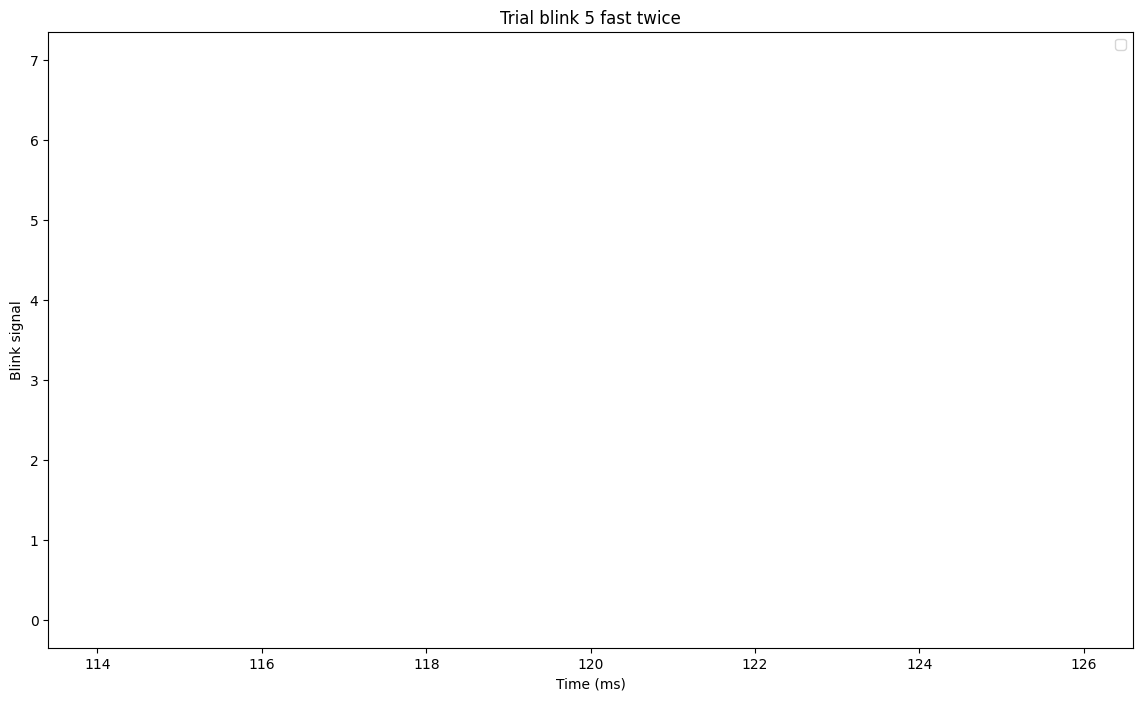

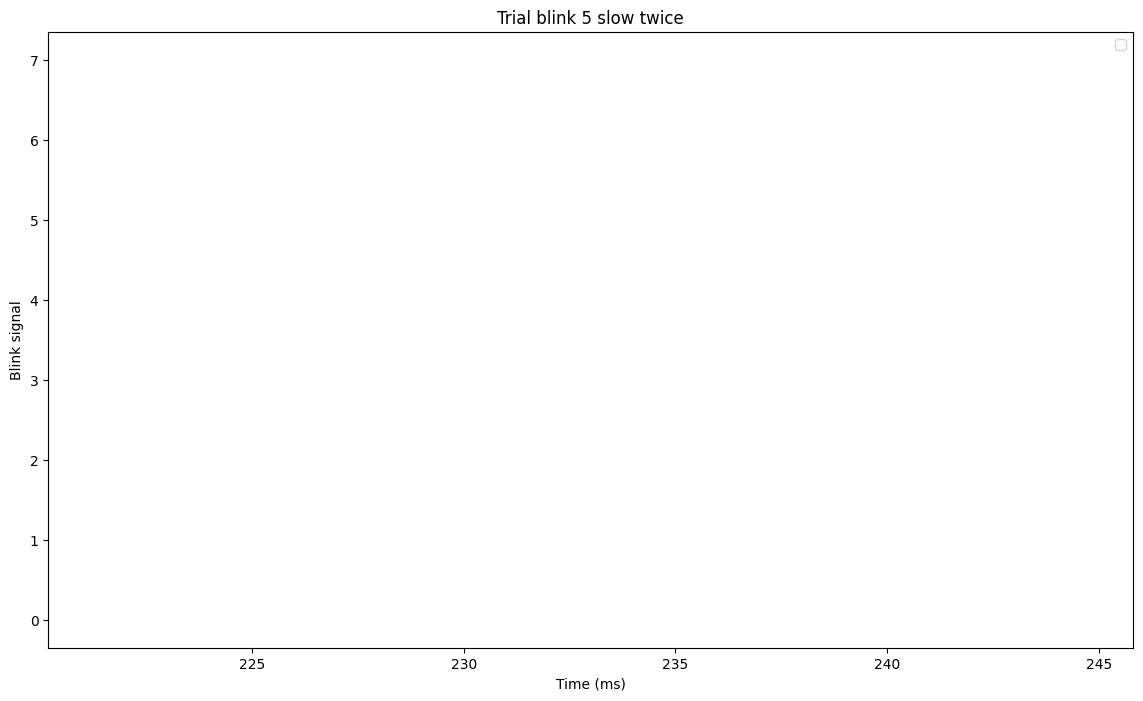

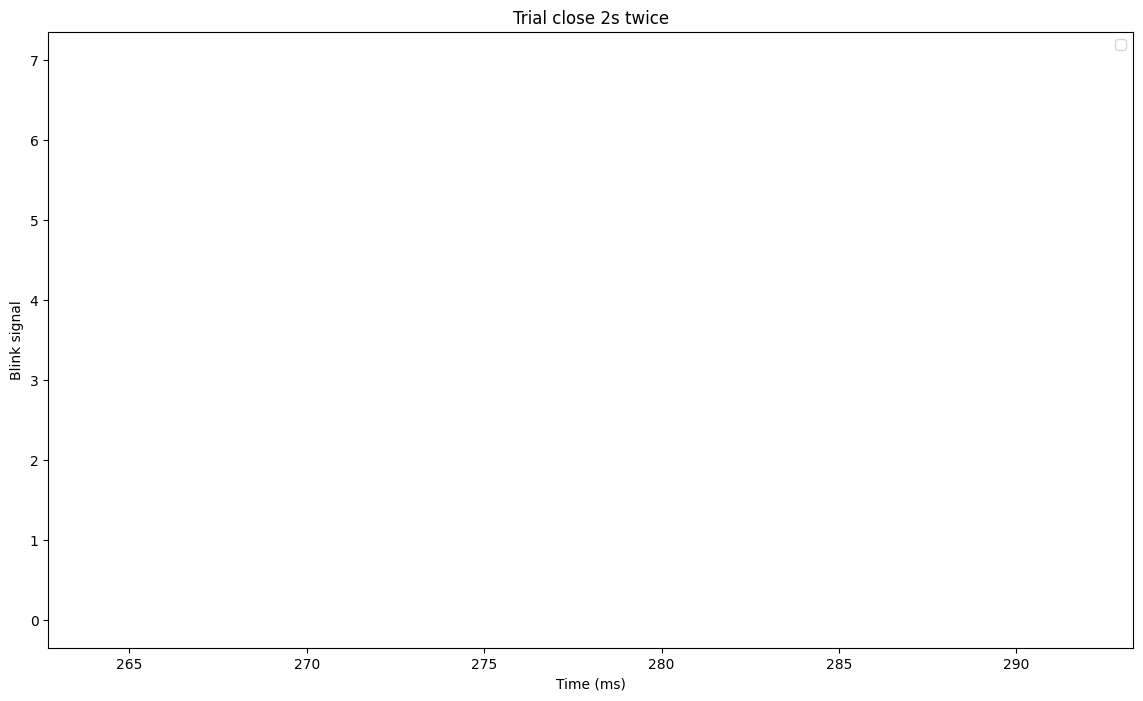

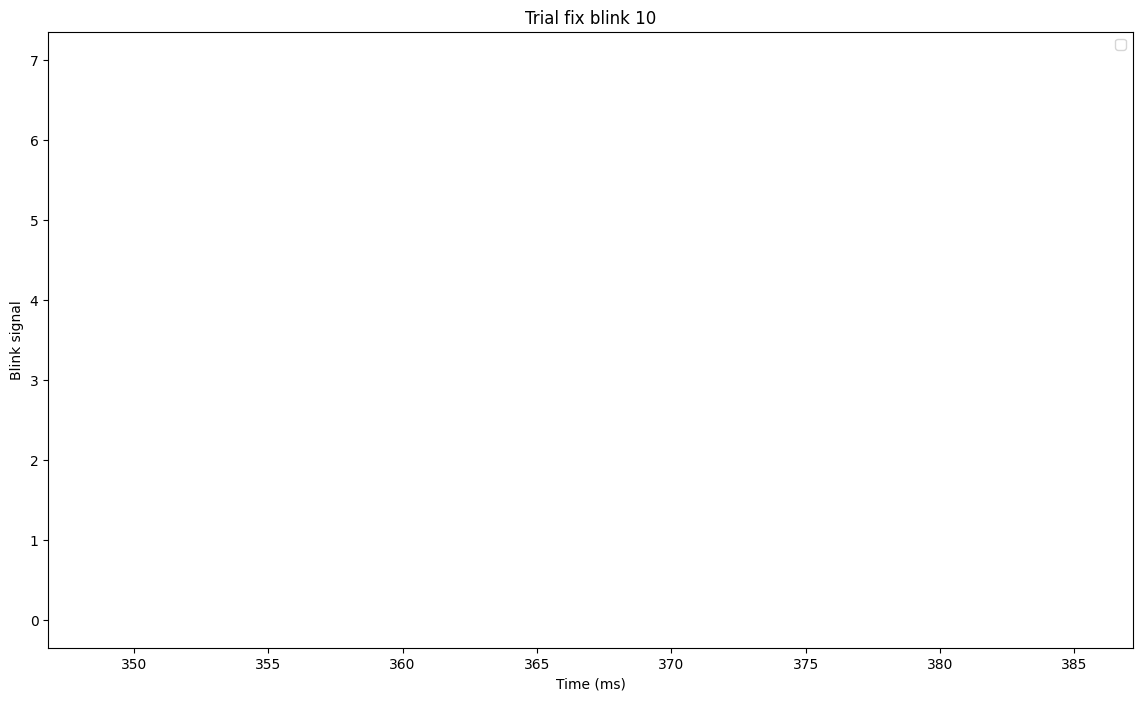

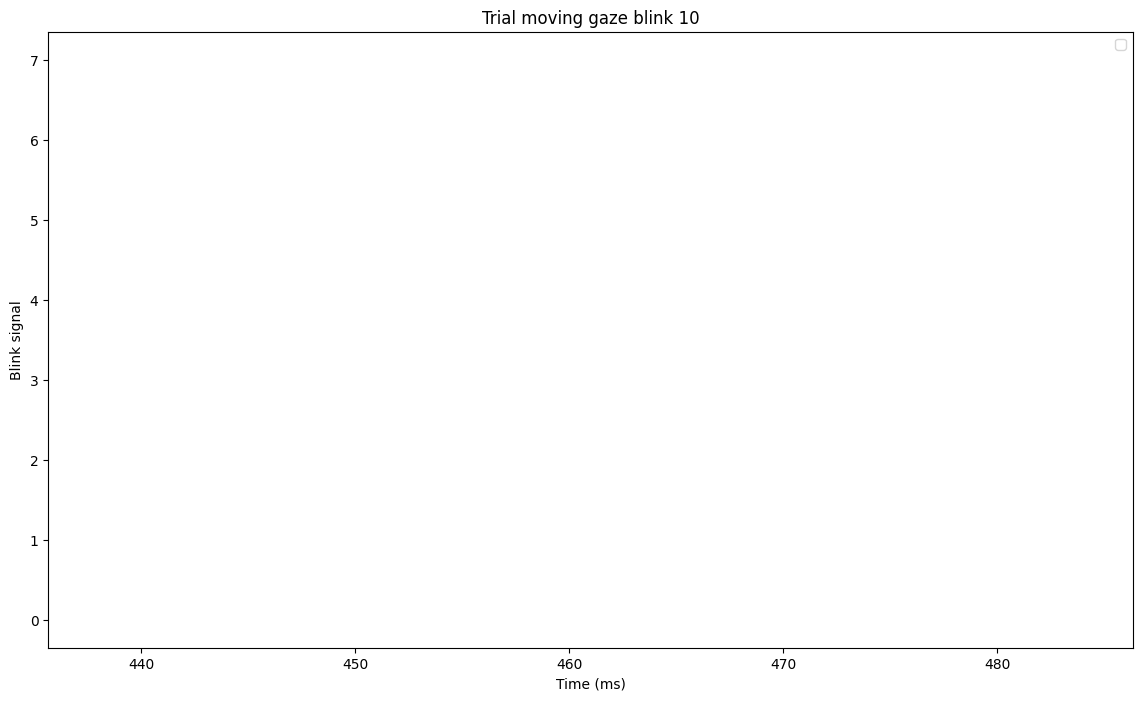

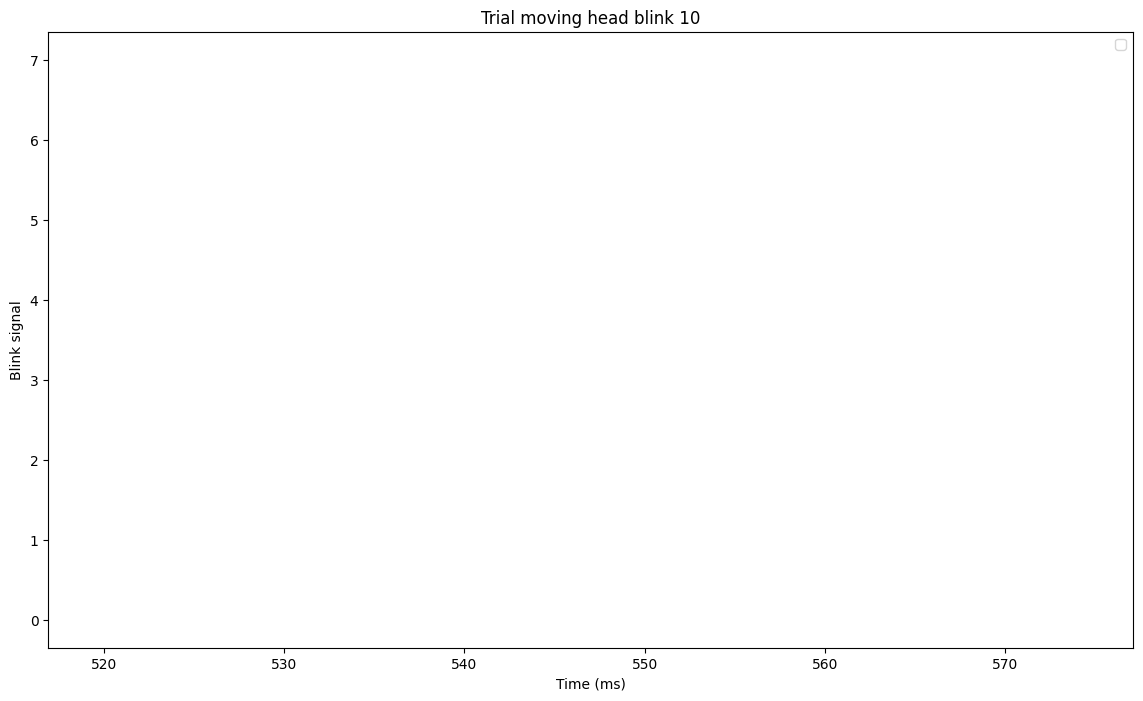

In [80]:
# Define the conditions for the different blink types
# Values for first threshold
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True)+5)
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[6]==True)+6)
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[7]==True)+7)


titles = ["Trial blink 5 fast twice",
          "Trial blink 5 slow twice",
          "Trial close 2s twice",
          "Trial fix blink 10",
          "Trial moving gaze blink 10",
          "Trial moving head blink 10"]

# Initialize the plot
plt.figure(figsize=(14, 8))

#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample", legend=False)
#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample1", legend=False)
for x in range(0,6):
  plt.figure(figsize=(14, 8))
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample1)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample2)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample3)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample4)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample5)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample6)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t , df_webgazer[df_webgazer["trial"]==x+1].Blink_sample7)
  plt.title(titles[x])
  plt.xlabel("Time (ms)")
  plt.ylabel("Blink signal")
  plt.legend(loc="upper right")
  plt.show()




# Plot the blink data using different colors for each type

# Add labels and legend
#plt.title("Blink Scatter Plot")
#plt.xlabel("Time (ms)")
#plt.ylabel("Trial")
#plt.legend(loc="upper right")

# Show plot
#plt.show()


In [ ]:
#GRAFICOS COLORS
# Define the conditions for the different blink types
# Values for first threshold
df_webgazer["Blink_sample"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[5]==True)+5)


titles = ["Trial blink 5 fast twice",
          "Trial blink 5 slow twice",
          "Trial close 2s twice",
          "Trial fix blink 10",
          "Trial moving gaze blink 10",
          "Trial moving head blink 10"]

# Initialize the plot
plt.figure(figsize=(14, 8))

#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample", legend=False)
#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Blink_sample1", legend=False)
for x in range(0,6):
  plt.figure(figsize=(14, 8))
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample1)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample2)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample3)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample4)
  plt.plot(df_webgazer[df_webgazer["trial"]==x+1].t ,df_webgazer[df_webgazer["trial"]==x+1].Blink_sample5)
  plt.title(titles[x])
  plt.xlabel("Time (ms)")
  plt.ylabel("Blink signal")
  plt.legend(loc="upper right")
  plt.show()




# Plot the blink data using different colors for each type

# Add labels and legend
#plt.title("Blink Scatter Plot")
#plt.xlabel("Time (ms)")
#plt.ylabel("Trial")
#plt.legend(loc="upper right")

# Show plot
#plt.show()


In [ ]:
# Define the conditions for the different blink types
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True))
df_webgazer[df_webgazer["trial"]==5]

In [ ]:
df_webgazer["isBlinkByEar"] = df_webgazer["isBlinkByEar"].map(
    lambda x: sum([int(i) for i in x])
)
df_webgazer[["t", "isBlinkByEar"]].plot.scatter(x="t", y="isBlinkByEar")

In [ ]:
row = 0
d = {}
df_list_tmp = []

for i, trial in enumerate(df_webgazer["trial"].unique()):
    df_list_tmp.append(df_webgazer.query(f"trial == {trial}"))
    if i > 1:
        d[f"row_{row}"] = pd.concat(df_list_tmp)
        row = row + 1
        i = 0
        df_list_tmp = []

In [ ]:
max_rows = 45
for i in range(20):
    if f"row_{i}" not in d:
        d[f"row_{i}"] = pd.DataFrame()  # Create an empty DataFrame for missing rows
    n_rows = d[f"row_{i}"].shape[0]
    if n_rows < max_rows:
        n_to_add = max_rows - n_rows

        # Pad data to ensure a consistent length
        for _ in range(n_to_add):
            data = {
                "x": [np.nan],
                "y": [np.nan],
                "t": [np.nan],
                "b": [False],
                "sample": [np.nan],
                "trial": [np.nan],
                "trial_type": [""],
            }
            new_row = pd.DataFrame(data)
            d[f"row_{i}"] = pd.concat([d[f"row_{i}"], new_row], ignore_index=True)


In [ ]:
# # Set up the figure
# fig, ax = plt.subplots(figsize=(10, 6))

# # Define colors for trial types
# color_map = {"red": "red", "green": "green"}

# # Iterate through each row (trial)
# for row in range(20):
#     df_row = d[f"row_{row}"]
#     df_row["b"] = df_row["b"].astype(int)

#     # Find the index where 't' is 0
#     zero_index = np.where(df_row["t"] == 0)[0]

#     # Check if there is more than one zero index
#     if len(zero_index) > 1:
#         # Shift 't' values for the second part of the trial
#         df_row["t"].iloc[zero_index[1] :] += df_row["t"].iloc[zero_index[1] - 1]

#     # Plot points based on "b" with black color, y-axis representing the "trial" column
#     ax.scatter(
#         df_row[df_row["b"] == 1]["t"],
#         df_row[df_row["b"] == 1]["trial"],
#         c="black",
#         s=40,
#         alpha=0.8,
#         label="Blinks",
#     )
#     ax.scatter(
#         df_row[(df_row["b"] == 0) & (df_row["t"] > 1000)]["t"],
#         df_row[(df_row["b"] == 0) & (df_row["t"] > 1000)]["trial"],
#         c="green",
#         s=30,
#         alpha=0.2,
#         label="No blink during red",
#     )
#     ax.scatter(
#         df_row[(df_row["b"] == 0) & (df_row["t"] <= 1000)]["t"],
#         df_row[(df_row["b"] == 0) & (df_row["t"] <= 1000)]["trial"],
#         c="red",
#         s=30,
#         alpha=0.2,
#         label="No blink during green",
#     )

# # Set labels and title
# ax.set_xlabel("time (ms)")
# ax.set_ylabel("Trial")

# ax.invert_yaxis()  # Invert the Y-axis